In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/unified_speeches.csv")

In [3]:
df.head()

,speaker,party,year,night,timestamp,speech,word_count,source_file,source
0,Rod O'connor,Democratic,2004,1,00:01:37,Good evening. On behalf of the dedicated leade...,400,www_c_span_transcripts2004-democratic-national...,CSPAN
1,Alice Huffman,Democratic,2004,1,00:04:39,"Welcome and thank you, delegates, for coming t...",384,www_c_span_transcripts2004-democratic-national...,CSPAN
2,Bill Richardson,Democratic,2004,1,00:06:08,"My fellow Democrats, the last time our party m...",506,www_c_span_transcripts2004-democratic-national...,CSPAN
3,Edward McElroy,Democratic,2004,1,00:08:05,"Thank you. Good evening, delegates, alternates...",397,www_c_span_transcripts2004-democratic-national...,CSPAN
4,Al Gore,Democratic,2004,1,00:09:18,Thank you. Thank you. Thank you very much. Tha...,1674,www_c_span_transcripts2004-democratic-national...,CSPAN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   speaker      1800 non-null   object
 1   party        1800 non-null   object
 2   year         1800 non-null   int64 
 3   night        1800 non-null   int64 
 4   timestamp    1800 non-null   object
 5   speech       1800 non-null   object
 6   word_count   1800 non-null   int64 
 7   source_file  1800 non-null   object
 8   source       1800 non-null   object
dtypes: int64(3), object(6)
memory usage: 126.7+ KB


In [5]:
df.loc[df['word_count'].idxmax()]

speaker                                             Donald Trump
party                                                 Republican
year                                                        2024
night                                                          4
timestamp                                               04:00:37
speech         Thank you very much. Thank you very, very much...
word_count                                                 11938
source_file    donald_trump_speaks_at_2024_republican_nationa...
source                                                       REV
Name: 1797, dtype: object

In [6]:
df.loc[df.groupby('party')['word_count'].idxmax()]

,speaker,party,year,night,timestamp,speech,word_count,source_file,source
926,Hillary Clinton,Democratic,2016,4,06:13:19,Thank you! Thank you all so much. Thank you. T...,5248,www_c_span_transcripts2016-democratic-national...,CSPAN
1797,Donald Trump,Republican,2024,4,04:00:37,"Thank you very much. Thank you very, very much...",11938,donald_trump_speaks_at_2024_republican_nationa...,REV


In [7]:
import re

In [8]:
I_PATTERN = re.compile(r"\bI\b|\bI'm\b|\bI've\b|\bI'll\b|\bI'd\b",  re.IGNORECASE)
WE_PATTERN = re.compile(r"\bwe\b|\bwe're\b|\bwe've\b|\bwe'll\b|\bwe'd\b", re.IGNORECASE)

In [9]:
df['i_count'] = df['speech'].apply(lambda x: len(I_PATTERN.findall(x)) if isinstance(x, str) else 0)
df['we_count'] = df['speech'].apply(lambda x: len(WE_PATTERN.findall(x)) if isinstance(x, str) else 0)

In [10]:
df.groupby('party')[['i_count', 'we_count']].sum()

,i_count,we_count
party,,
Democratic,8246,10077
Republican,6220,6131


In [11]:
df['i_rate'] = (df['i_count'] / df['word_count']) * 1000
df['we_rate'] = (df['we_count'] / df['word_count']) * 1000

df.groupby('party')[['i_count','we_count','i_rate', 'we_rate']].mean().round(2)

,i_count,we_count,i_rate,we_rate
party,,,,
Democratic,6.57,8.02,17.54,18.53
Republican,11.43,11.27,16.80,16.36


In [12]:
df['collective_gap'] = df['we_rate'] - df['i_rate']

df.groupby(['year', 'party'])[['i_rate', 'we_rate', 'collective_gap']].mean()

i_rate    we_rate  collective_gap
year party                                           
2004 Democratic  13.105368  18.415180        5.309813
     Republican  14.192916  15.782145        1.589229
2008 Democratic  14.431105  18.317998        3.886892
     Republican  15.972961  14.287696       -1.685264
2012 Democratic  14.932156  16.741163        1.809007
     Republican  13.502969  20.636845        7.133876
2016 Democratic  21.338337  17.050973       -4.287364
     Republican  15.798092  17.108965        1.310873
2020 Democratic  18.690704  20.771550        2.080846
     Republican  20.848512  13.276064       -7.572449
2024 Democratic  18.966937  17.910682       -1.056255
     Republican  18.380415  16.385082       -1.995333

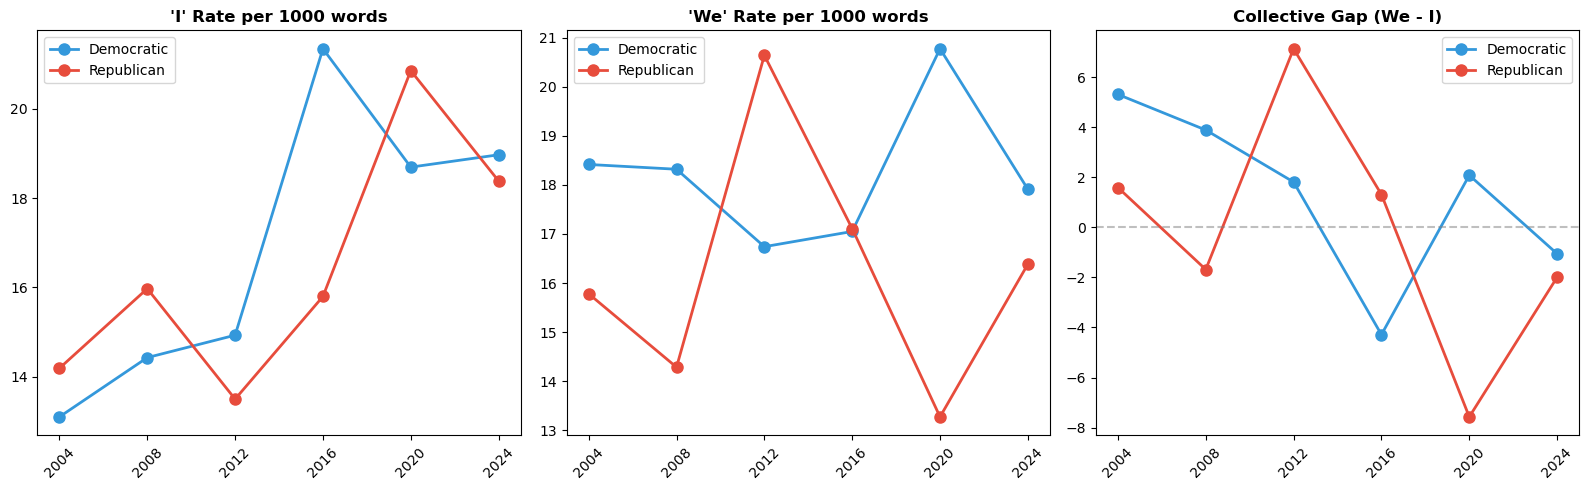

In [13]:
year_party = df.groupby(['year', 'party'])[['i_rate', 'we_rate', 'collective_gap']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
PARTY_COLORS = {'Democratic': '#3498db', 'Republican': '#e74c3c'}

for ax, col, title in zip(axes, 
    ['i_rate', 'we_rate', 'collective_gap'],
    ["'I' Rate per 1000 words", "'We' Rate per 1000 words", "Collective Gap (We - I)"]):
    for party in ['Democratic', 'Republican']:
        data = year_party[year_party['party'] == party]
        ax.plot(data['year'], data[col], 'o-', label=party,
                color=PARTY_COLORS[party], markersize=8, linewidth=2)
    if col == 'collective_gap':
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(year_party['year'].unique())
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# gap between parties over time
year_party = df.groupby(['year', 'party'])[['i_rate', 'we_rate', 'collective_gap']].mean().reset_index()

dem = year_party[year_party['party'] == 'Democratic'].set_index('year')
rep = year_party[year_party['party'] == 'Republican'].set_index('year')

party_diff = pd.DataFrame({
    'i_rate_diff': abs(dem['i_rate'] - rep['i_rate']),
    'we_rate_diff': abs(dem['we_rate'] - rep['we_rate']),
    'gap_diff': abs(dem['collective_gap'] - rep['collective_gap'])
})

print("Absolute difference between parties by year:")
print(party_diff.round(2))

Absolute difference between parties by year:
      i_rate_diff  we_rate_diff  gap_diff
year                                     
2004         1.09          2.63      3.72
2008         1.54          4.03      5.57
2012         1.43          3.90      5.32
2016         5.54          0.06      5.60
2020         2.16          7.50      9.65
2024         0.59          1.53      0.94


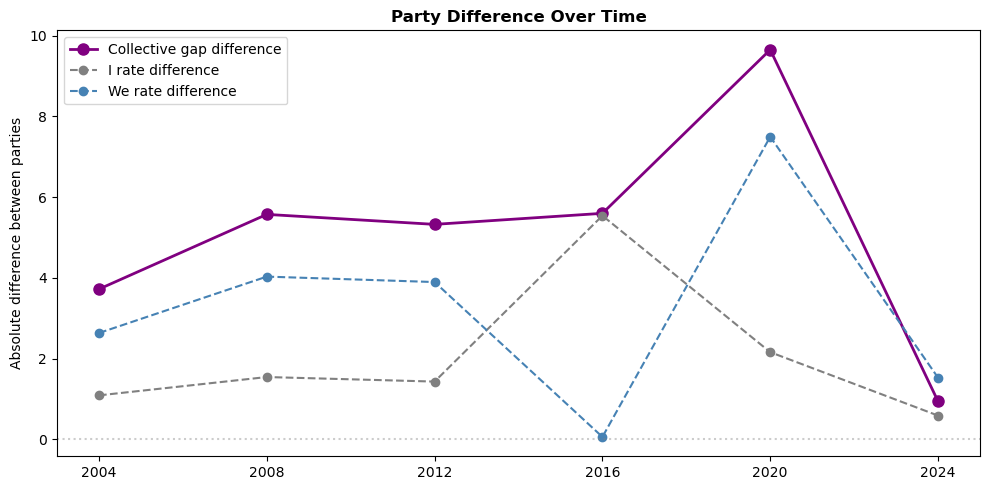

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(party_diff.index, party_diff['gap_diff'], 'o-', 
        color='purple', markersize=8, linewidth=2, label='Collective gap difference')
ax.plot(party_diff.index, party_diff['i_rate_diff'], 'o--', 
        color='gray', markersize=6, linewidth=1.5, label='I rate difference')
ax.plot(party_diff.index, party_diff['we_rate_diff'], 'o--', 
        color='steelblue', markersize=6, linewidth=1.5, label='We rate difference')

ax.axhline(y=0, color='gray', linestyle=':', alpha=0.4)
ax.set_title('Party Difference Over Time', fontweight='bold')
ax.set_ylabel('Absolute difference between parties')
ax.set_xticks([2004, 2008, 2012, 2016, 2020, 2024])
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Top I-rate speakers 2020 RNC
df[(df['year'] == 2020) & (df['party'] == 'Republican') & (df['word_count'] > 300)]\
    .sort_values('i_rate', ascending=False)\
    [['speaker', 'i_rate', 'we_rate', 'collective_gap', 'word_count']].head(10)

,speaker,i_rate,we_rate,collective_gap,word_count
1443,Alice Johnson,68.907563,3.361345,-65.546218,595
1402,Kayleigh McEnany,62.695925,0.000000,-62.695925,638
1370,Maximo Alvarez,60.790274,3.039514,-57.750760,658
1409,Madison Cawthorn,54.229935,13.015184,-41.214751,461
1420,Sam Vigil,45.901639,3.278689,-42.622951,305
1354,Tanya Weinreis,45.454545,23.923445,-21.531100,418
1401,Tera Myers,45.454545,16.233766,-29.220779,308
1429,Stacia Brightmon,42.500000,0.000000,-42.500000,400
1427,Jeff Van Drew,40.983607,8.196721,-32.786885,610
1426,Ja'Ron Smith,36.363636,0.000000,-36.363636,440


In [17]:
# Top I-rate speakers 2004 DNC
df[(df['year'] == 2024) & (df['party'] == 'Democratic') & (df['word_count'] > 300)]\
    .sort_values('collective_gap', ascending=True)\
    [['speaker', 'i_rate', 'we_rate', 'collective_gap', 'word_count']].head(10)

,speaker,i_rate,we_rate,collective_gap,word_count
1635,D.L. Hughley,49.603175,3.968254,-45.634921,504
1579,Lateefa Simon,39.787798,2.652520,-37.135279,377
1507,Ashley Biden,34.899329,4.026846,-30.872483,745
1482,Eleni Kounalakis,38.216561,12.738854,-25.477707,314
1593,Alex Padilla,35.326087,10.869565,-24.456522,368
1567,Geoff Duncan,29.268293,4.878049,-24.390244,410
1574,Mindy Kaling,37.924152,13.972056,-23.952096,501
1530,Doug Emhoff,35.190616,11.730205,-23.460411,1705
1489,Steve Kerr,31.553398,8.495146,-23.058252,824
1650,Adam Kinzinger,30.707610,8.010681,-22.696929,749


In [18]:
df[df['speaker'] == 'Donald Trump'][['speaker', 'party', 'year', 'i_rate', 'we_rate', 'collective_gap', 'word_count']]

,speaker,party,year,i_rate,we_rate,collective_gap,word_count
1004,Donald Trump,Republican,2016,16.602229,13.873095,-2.729134,4397
1392,Donald Trump,Republican,2020,0.000000,0.000000,0.000000,132
1445,Donald Trump,Republican,2020,8.893425,25.659717,16.766292,6859
1797,Donald Trump,Republican,2024,21.444128,24.040878,2.596750,11938


In [19]:
df[df['speaker'] == 'Barack Obama'][['speaker', 'party', 'year', 'i_rate', 'we_rate', 'collective_gap', 'word_count']]

,speaker,party,year,i_rate,we_rate,collective_gap,word_count
79,Barack Obama,Democratic,2004,13.667426,16.400911,2.733485,2195
390,Barack Obama,Democratic,2008,17.256072,16.403920,-0.852152,4694
590,Barack Obama,Democratic,2012,17.987152,21.841542,3.854390,4670
858,Barack Obama,Democratic,2016,14.419611,15.621245,1.201634,4161
1238,Barack Obama,Democratic,2020,11.406844,12.547529,1.140684,2630
1335,Barack Obama,Democratic,2020,0.000000,0.000000,0.000000,149
1532,Barack Obama,Democratic,2024,8.756567,26.561588,17.805020,3426


In [20]:
# all the nominees in these years
nominees = ['Barack Obama', 'John Kerry', 'Hillary Clinton', 'Joe Biden', 
            'Kamala Harris', 'Donald Trump', 'Mitt Romney', 'John McCain',
            'Sarah Palin', 'John Edwards', 'Tim Walz', 'J.D. Vance',
            'Mike Pence', 'George W. Bush', 'Dick Cheney',
            'Paul Ryan', 'Tim Kaine']

nominee_years = {
    'John Kerry':      [2004],
    'John Edwards':    [2004],
    'George W. Bush':  [2004],
    'Dick Cheney':     [2004],
    'Barack Obama':    [2008, 2012],
    'Joe Biden':       [2008, 2012],
    'John McCain':     [2008],
    'Sarah Palin':     [2008],
    'Mitt Romney':     [2012],
    'Paul Ryan':       [2012],
    'Hillary Clinton': [2016],
    'Tim Kaine':       [2016],
    'Donald Trump':    [2016, 2020, 2024],
    'Mike Pence':      [2016, 2020],
    'Kamala Harris':   [2024],
    'Tim Walz':        [2024],
    'J.D. Vance':      [2024],  
}

nominees_df = df[df['speaker'].isin(nominees)]\
    [['speaker', 'party', 'year', 'i_rate', 'we_rate', 'collective_gap', 'word_count']]\
    .sort_values(['speaker', 'year'])
nominees_df

,speaker,party,year,i_rate,we_rate,collective_gap,word_count
79,Barack Obama,Democratic,2004,13.667426,16.400911,2.733485,2195
390,Barack Obama,Democratic,2008,17.256072,16.403920,-0.852152,4694
590,Barack Obama,Democratic,2012,17.987152,21.841542,3.854390,4670
858,Barack Obama,Democratic,2016,14.419611,15.621245,1.201634,4161
1238,Barack Obama,Democratic,2020,11.406844,12.547529,1.140684,2630
1335,Barack Obama,Democratic,2020,0.000000,0.000000,0.000000,149
1532,Barack Obama,Democratic,2024,8.756567,26.561588,17.805020,3426
239,Dick Cheney,Republican,2004,9.996298,15.179563,5.183265,2701
1004,Donald Trump,Republican,2016,16.602229,13.873095,-2.729134,4397
1392,Donald Trump,Republican,2020,0.000000,0.000000,0.000000,132


In [21]:
# compare nominee year vs non-nominee year
nominees_df['role'] = nominees_df.apply(
    lambda row: 'Nominee' if row['year'] in nominee_years.get(row['speaker'], []) else 'Non-Nominee', axis=1
)

nom_year = nominees_df.groupby(['speaker', 'role'])[['i_rate', 'we_rate', 'collective_gap']].mean()
print(nom_year)

                                i_rate    we_rate  collective_gap
speaker         role                                             
Barack Obama    Nominee      17.621612  19.122731        1.501119
                Non-Nominee   9.650090  14.226254        4.576165
Dick Cheney     Nominee       9.996298  15.179563        5.183265
Donald Trump    Nominee      11.734945  15.893423        4.158477
George W. Bush  Nominee      15.357354  22.248474        6.891120
                Non-Nominee  19.450801   9.153318      -10.297483
Hillary Clinton Nominee      15.243902  21.913110        6.669207
                Non-Nominee   9.958720  16.121241        6.162521
J.D. Vance      Nominee      22.152798  16.188583       -5.964215
Joe Biden       Nominee      18.056362  24.710453        6.654092
                Non-Nominee  31.325662  17.984378      -13.341284
John Edwards    Nominee      13.302635  34.535687       21.233052
John Kerry      Nominee      20.372862  25.369979        4.997117
          

In [22]:
incumbent_map = {
    2004: 'Republican',
    2008: 'Republican', 
    2012: 'Democratic',
    2016: 'Democratic',
    2020: 'Republican',
    2024: 'Democratic',
}

df['is_incumbent_party'] = df.apply(
    lambda x: 'Incumbent' if incumbent_map.get(x['year']) == x['party'] else 'Challenger', axis=1
)

df.groupby(['year', 'is_incumbent_party'])[['i_rate', 'we_rate', 'collective_gap']].mean()

i_rate    we_rate  collective_gap
year is_incumbent_party                                      
2004 Challenger          13.105368  18.415180        5.309813
     Incumbent           14.192916  15.782145        1.589229
2008 Challenger          14.431105  18.317998        3.886892
     Incumbent           15.972961  14.287696       -1.685264
2012 Challenger          13.502969  20.636845        7.133876
     Incumbent           14.932156  16.741163        1.809007
2016 Challenger          15.798092  17.108965        1.310873
     Incumbent           21.338337  17.050973       -4.287364
2020 Challenger          18.690704  20.771550        2.080846
     Incumbent           20.848512  13.276064       -7.572449
2024 Challenger          18.380415  16.385082       -1.995333
     Incumbent           18.966937  17.910682       -1.056255

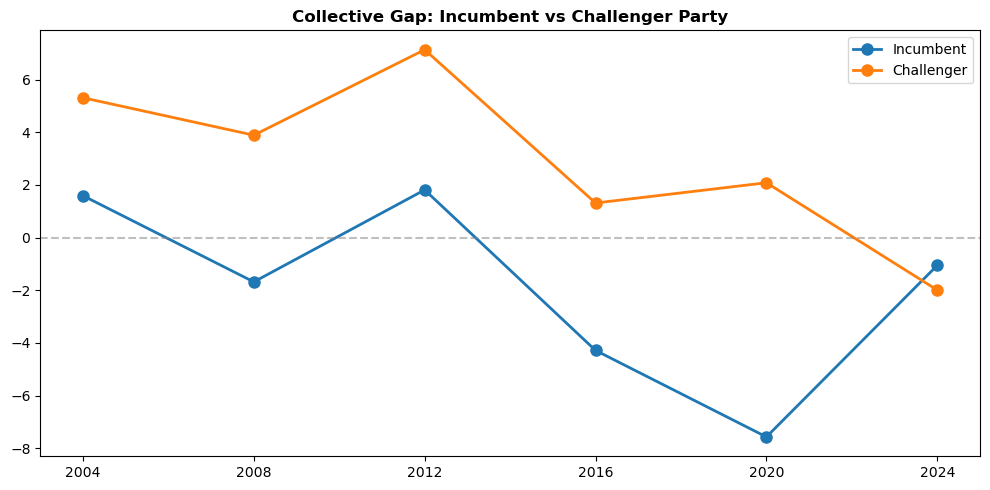

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

for role in ['Incumbent', 'Challenger']:
    data = df.groupby(['year', 'is_incumbent_party'])[['collective_gap']].mean().reset_index()
    data = data[data['is_incumbent_party'] == role]
    ax.plot(data['year'], data['collective_gap'], 'o-', label=role, markersize=8, linewidth=2)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Collective Gap: Incumbent vs Challenger Party', fontweight='bold')
ax.set_xticks([2004, 2008, 2012, 2016, 2020, 2024])
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
print(df[df['word_count'] < 215]['i_rate'].mean())   
print(df[df['word_count'] >= 215]['i_rate'].mean())  

20.23553994975594
16.079664853034135


In [25]:
total = len(df)
should_drop = len(df[df['word_count'] < 215])
print(f"{should_drop} of {total} speeches are under 215 words ({should_drop/total*100:.1f}%)")

537 of 1800 speeches are under 215 words (29.8%)


In [26]:
df['i_rate'].mean()

np.float64(17.31950092355614)

In [27]:
df['we_rate'].mean()

np.float64(17.87747093394433)